# Homophily

> Computational Analysis of Social Complexity
>
> Fall 2025, Spencer Lyon

**Prerequisites**

- Introduction to Graphs
- Strong and Weak Ties

**Outcomes**

- Understand the concept of homophily
- Practice working through "by hand" examples of diagnosing homophily
- Be prepared to computationally diagnose homophily in a large network

**References**

- [Easley and Kleinberg](https://www.cs.cornell.edu/home/kleinber/networks-book/) chapter 4 (especially section 4.1)

**Datasets**

- Florentine family relationships: https://www.cs171.org/2018/assets/instructions/lab8/Lab8.html

## Introduction

### Main Idea

- Consider your friends. Do they tend to 
  - Enjoy the same movies, music, hobbies as you?
  - Hold similar religious or political beliefs?
  - Come from similar schools, workplaces, or socio-economic settings?
- What about a random sample of people in the world?
- If you are like me, your answers likely indicate that you have more in common with your friends than you would expect to have with a random sample of people
- This concept -- that we are similar to our friends -- is called **homophily**

### Homophily in Graphs

- In the context of graphs or networks, homophily means that nodes that are connected are *more similar* than nodes at a further distance in the graph
- But what do we mean by *more similar*?
  - Idea: We might have common friends. 
    - This is an **intrinsic** force that led to node formation (e.g. triadic closure)
  - Alternative: We may share characteristics or properties that are not represented in the graph -- **external** forces. 
    - Examples: same race, gender, school, employer, sports team, etc.
- These external forces are what homophily captures

### Context

- To identify if homophily is active in a network, we must have access to **context** on top of list of nodes and edges
- One way to represent this context would be with a DataFrame in addition to a graph:
  - One row per node
  - One column indicating the node identifier (or just use row number)
  - One column for additional characteristic

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


df_all = pd.read_csv("florentine-familiy-attributes.csv", na_values="NA")
df_all.columns = ["family", "wealth", "priorates"]

# The Pucci family has no marriage or business ties in this dataset (an
# isolated node), so we drop it here to match the 15-family network below
df1 = df_all[df_all["family"] != "Pucci"].reset_index(drop=True)
df1

,family,wealth,priorates
0,Acciaiuoli,10,53.0
1,Albizzi,36,65.0
2,Barbadori,55,NaN
3,Bischeri,44,12.0
4,Castellani,20,22.0
5,Ginori,32,NaN
6,Guadagni,8,21.0
7,Lamberteschi,42,0.0
8,Medici,103,53.0
9,Pazzi,48,NaN


* It will be easier to do our homohpily calculations with binary data,
* we'll create new columns, `high_wealth` and `high_power` if the wealth and priorates columns, respectively, are above the column medians

In [2]:
df1["high_wealth"] = df1["wealth"] > df1["wealth"].median()
df1["high_power"] = df1["priorates"] > df1["priorates"].median()
df1.loc[df1["priorates"].isna(), "high_power"] = False
df1

,family,wealth,priorates,high_wealth,high_power
0,Acciaiuoli,10,53.0,False,True
1,Albizzi,36,65.0,False,True
2,Barbadori,55,NaN,True,False
3,Bischeri,44,12.0,True,False
4,Castellani,20,22.0,False,False
5,Ginori,32,NaN,False,False
6,Guadagni,8,21.0,False,False
7,Lamberteschi,42,0.0,False,False
8,Medici,103,53.0,True,True
9,Pazzi,48,NaN,True,False


In [3]:
def load_lg_graph(path, node_names):
    """Load a LightGraphs.jl-style edge list file into a networkx graph.

    `node_names` gives the label to use for the 1-indexed node ids stored
    in the file (in file order).
    """
    with open(path) as f:
        n_nodes, _n_edges, directed = f.readline().strip().split(",")[:3]
        n_nodes = int(n_nodes)
        graph_type = nx.DiGraph if directed == "d" else nx.Graph
        G = graph_type()
        G.add_nodes_from(node_names[:n_nodes])
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(",")
            src, dst = node_names[int(parts[0]) - 1], node_names[int(parts[1]) - 1]
            if len(parts) > 2:
                G.add_edge(src, dst, weight=float(parts[2]))
            else:
                G.add_edge(src, dst)
    return G


g1_all = load_lg_graph("marriages.lg", list(df_all["family"]))
g1 = g1_all.copy()
g1.remove_node("Pucci")

# The businesses network (same families) is bundled for use in the homework
# exercise on counting edge types; loaded here for convenience
businesses_g = load_lg_graph("businesses.lg", list(df_all["family"]))
businesses_g.remove_node("Pucci")

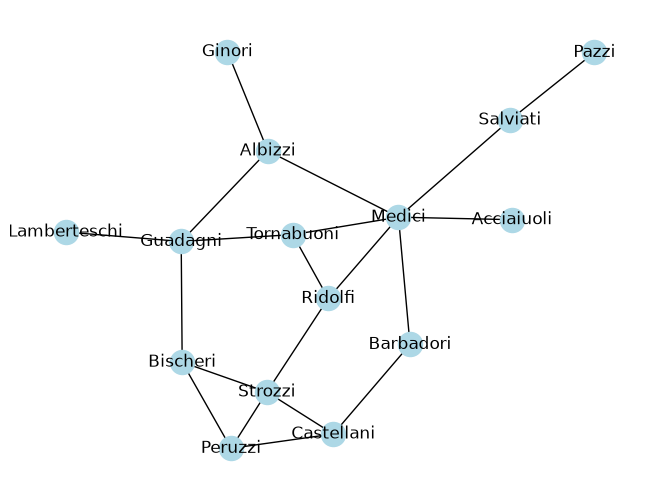

In [4]:
pos1 = nx.spring_layout(g1, seed=6318)
nx.draw(g1, pos1, with_labels=True, node_color="lightblue")
plt.show()

## Measuring Homophily

- Our discussion on homophily so far has been conceptual... let's make it precise
- We'll frame the discussion in terms of a null hypothesis
- Concept should be familiar from statistics, but not exactly the same we we won't make distributional assumptions

### Random Homophily

- Our analytical approach begins with a thought experiment (counter factual) that all edges are randomly formed
- In this case, we should not expect the context around our graph to help us predict its structure
- Suppose we consider a characteristic $X$
- We have $N$ nodes and $N_x$ of them exhibit feature $X$ and $N - N_x$ of them to not
  - We'll work with probabilities: $p_x = \frac{N_x}{N}$
- The probability that an arbitrary edge is between two nodes that both share $X$ is equal to $p_x^2$
  - Probability of edge between two non $X$ nodes: $(1-p_x)^2$
  - Probabillity of edge bewtween one $X$ and one non $X$: 
$$\begin{aligned}\text{prob}(\text{edge (X <=> not X)}) &= p_x (1-p_x) + (1-p_x) p_x \\ &= 2 p_x (1-p_x)\end{aligned}$$
- This will be our "random edge formation" benchmark

### Counting Frequencies

- Now an empirical value...
- Let there be $e$ edges
- Let...

| variable | meaning |
|----------|---------|
| $e_{xx}$ | # edges between 2 $X$ |
| $e_{yy}$ | # edges between 2 not $X$ |
| $e_{xy}$ | # edges between 1 $X$  and 1 not $X$|




- Then $e = e_{xx} + e_{yy} + e_{xy}$
- We'll use these 4 numbers to count frequencies of edges between $X$ types and non-$X$ types

### Testing for Homophily

- We are now ready to test for homophily
- We'll consider the assumption (null hypothesis) that there is no homophily in characteristic $X$
    - $\Longrightarrow$ observed proportion of cross-characteristic edges is (approximately) the same as characteristic frequencies in the full population
- To test this assumption, we compare
  - $2 p_x(1-p_x)$: the likelihood of a cross-characteristic edge forming, under the assumption of purely random edge formation
  - $\frac{e_{xy}}{e}$: the proportion of cross-characteristic edges that exist in the network
- When comparing these statistics, we could get one of three outcomes:

| Condition | result |
| --------- | ------ |
| $$\frac{e_{xy}}{e} >> 2 p_x(1-p_x)$$ | inverse homophily |
| $$\frac{e_{xy}}{e} \approx 2 p_x(1-p_x)$$ | no homophily |
| $$\frac{e_{xy}}{e} << 2 p_x(1-p_x)$$ | homophily |
 
- Intuition: If observed cross characteristic edge formation is significantly less than what we'd expected under random edge formation, we reject the hypothesis that homophily is not present, and conclude that characteristic $X$ is meaningful for edge formation

### Example: high school relationships

- Recall the graph of romantic relationships between high school students
- **Question**: does this graph exhibit homophily in gender? Why?

![hs_dating_graph.png](https://github.com/sglyon/ucf-cap-6318/raw/Fall21/notebooks/week03/hs_dating_graph.png)

## Example: Florentines

- Let's work through an example of numerically dianosing homophily using the Florentine data
- I'll repeat the data below

In [5]:
df1

,family,wealth,priorates,high_wealth,high_power
0,Acciaiuoli,10,53.0,False,True
1,Albizzi,36,65.0,False,True
2,Barbadori,55,NaN,True,False
3,Bischeri,44,12.0,True,False
4,Castellani,20,22.0,False,False
5,Ginori,32,NaN,False,False
6,Guadagni,8,21.0,False,False
7,Lamberteschi,42,0.0,False,False
8,Medici,103,53.0,True,True
9,Pazzi,48,NaN,True,False


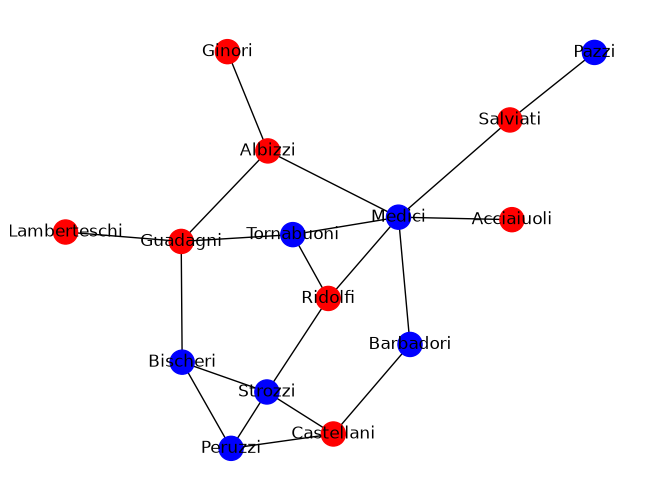

In [6]:
node_color = ["blue" if x else "red" for x in df1["high_wealth"]]
pos1 = nx.spring_layout(g1, seed=6318)
nx.draw(g1, pos1, with_labels=True, node_color=node_color)
plt.show()

### Step 1: Counting frequencies

- First we need to count frequencies for all our characteristics
- We'll do that here

In [7]:
from collections import Counter

In [8]:
def count_frequencies(vals):
    counts = Counter(vals)
    total = len(vals)
    return {c: v / total for c, v in counts.items()}

In [9]:
count_frequencies(df1["high_wealth"])

{False: 0.5333333333333333, True: 0.4666666666666667}

In [10]:
{n: count_frequencies(df1[n]) for n in df1.columns[3:]}

{'high_wealth': {False: 0.5333333333333333, True: 0.4666666666666667},
 'high_power': {True: 0.3333333333333333, False: 0.6666666666666666}}

### Step 2: Counting Edges

- Next we need to count the number of edges of each type
- This step is a bit tricker as it will require that we access both data from the Graph and the DataFrame
- To not spoil the fun, we'll leave this code as an exercise on the homework
- For now we'll look at things "by hand"

- Let's consider `high_wealth` and test if marriages where influenced by mutual wealth
- Data: We have 7 high wealth families in the dataset
- Counting edge types for high_wealth vs non high_wealth:
  - high-high edges: 6
  - low-low edges: 3
  - Cross edges (high to low): 11
- Total: 11 + 6 + 3 = 20 edges ✓
- The ratio of cross edges is 11/20 = 0.55
- The ratio of nodes that are high is 7/15 = 0.46 ($p_x$)

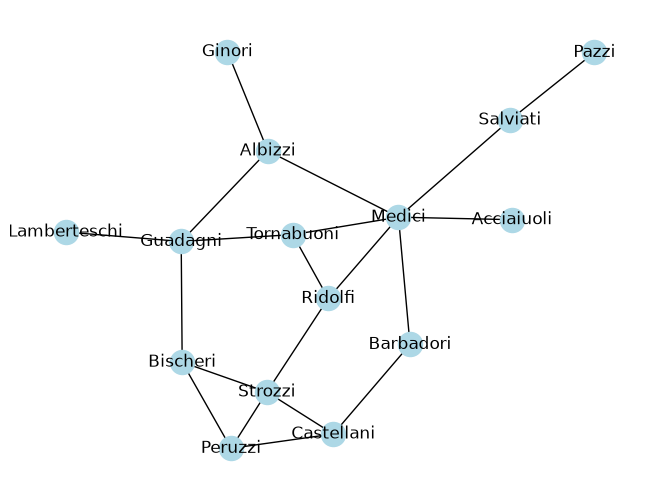

In [11]:
pos1 = nx.spring_layout(g1, seed=6318)
nx.draw(g1, pos1, with_labels=True, node_color="lightblue")
plt.show()

In [12]:
E = g1.number_of_edges()
Exy = 11  # cross edges
n_high = 7
N = g1.number_of_nodes()
px = n_high / N

# test
2 * px * (1 - px), Exy / E

(0.49777777777777776, 0.55)

- Here we have that the actual proportion of cross edges (0.55) is slightly higher than what we'd expect under random formation (0.5)
- This suggests a very mild instance of *inverse homophily* (opposites attract), though the difference is quite small
- This does make some sense, as anecdotally we have heard tales of parents desiring their daughters to marry into a wealthy family

### Exercise

- Repeat the counting exercise, but for the high_power characteristic
- What do you find? Do you see homophily in this characteristic?